# ETT Dataset — Classical ML Forecasting Baselines
*(the honest bar to beat before any deep model)*

Picks up where `ett_eda.ipynb` and `ett_transformer_analysis.ipynb` left off. The EDA gave us the
physics — thermal lag, seasonality, diurnal load. This notebook asks the forecasting question a field
electrical engineer would actually ask: **can I predict oil temperature a day / a week ahead from data
I already have, with tools that run on a laptop?**

Deliberately no deep learning here. Before anyone quotes an Informer-style transformer forecast, we
need the boring baselines — persistence, a "same hour last week" copy, linear regression, random
forest, gradient boosting. If a 400-line attention model can't beat these by a wide margin on your
data, it isn't doing anything useful.

**Notebook lineage:** this is the modeling pass for the ETT datasets in `python/datasets/`. All four
files are used; the main benchmark runs on **ETTh1** (Transformer 1, hourly, two years).

## 1. Setup — data, and the one rule that makes or breaks a forecast

Rule: **never shuffle time-series data**. A model trained on July-2017 rows and tested on January-2017
rows is cheating — it has already seen the future. We split strictly by time: first 70% for training,
next 10% for validation, last 20% for test, in that order.

The forecast task is framed the way an O&M engineer would think about it: predict **OT (top-oil
temperature, °C)** at horizons of **1h, 6h, 24h, 48h and 168h (one week)**. Each horizon gets its own
model — a *direct* strategy — using features visible at time `t` to predict OT at `t+h`.

In [1]:
# sklearn's gradient-boosting uses OpenMP; the default thread count (= all cores)
# thrashes on barriers under load and is often *slower* than a small pool.
# Set before importing sklearn. Tune OMP_NUM_THREADS on your machine.
import os
os.environ["OMP_NUM_THREADS"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

# Product-palette colors (matches the Zuttoo console theme)
INK, TEAL, AMBER, RED, SLATE = "#0f172a", "#0d9488", "#f2b441", "#f0605d", "#64748b"

DATASETS = {
    "ETTh1": ("ETTh1.csv", 1),   # Transformer 1, hourly
    "ETTh2": ("ETTh2.csv", 1),   # Transformer 2, hourly
    "ETTm1": ("ETTm1.csv", 4),   # Transformer 1, 15-min
    "ETTm2": ("ETTm2.csv", 4),   # Transformer 2, 15-min
}

def resolve(name):
    for base in ("datasets", "."):
        p = os.path.join(base, name)
        if os.path.exists(p):
            return p
    return name

dfs = {name: pd.read_csv(resolve(path), parse_dates=["date"]).set_index("date")
       for name, (path, _) in DATASETS.items()}
for name, df in dfs.items():
    print(f"{name}: {df.shape[0]:>6} rows · {df.index.min()} → {df.index.max()} · {df.shape[1]} channels")

ETTh1:  17420 rows · 2016-07-01 00:00:00 → 2018-06-26 19:00:00 · 7 channels
ETTh2:  17420 rows · 2016-07-01 00:00:00 → 2018-06-26 19:00:00 · 7 channels
ETTm1:  69680 rows · 2016-07-01 00:00:00 → 2018-06-26 19:45:00 · 7 channels
ETTm2:  69680 rows · 2016-07-01 00:00:00 → 2018-06-26 19:45:00 · 7 channels


## 2. The benchmark protocol

- **Horizons:** 1, 6, 24, 48, 168 hours.
- **Metrics:** MAE and RMSE in °C (units a thermal engineer reads directly), MAPE in %.
  MAPE uses a 1°C floor on the denominator — OT crosses 0°C in this dataset, and textbook
  MAPE would divide by near-zero readings and explode (see §8).
- **Split:** 70 / 10 / 20 by time, recomputed per horizon (each horizon drops its own tail, so the
  last `h` rows never get a fake target).
- **Strategy:** direct — one model per horizon; features at `t` → target at `t+h`.

In [2]:
HORIZONS_H = [1, 6, 24, 48, 168]     # forecast horizons, in hours
TRAIN, VAL, TEST = 0.7, 0.1, 0.2     # strict temporal split

def split_rows(n):
    tr = int(n * TRAIN)
    va = int(n * (TRAIN + VAL))
    return np.arange(tr), np.arange(tr, va), np.arange(va, n)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    # MAPE with a 1°C floor on the denominator: OT crosses 0°C in this dataset
    # (111 rows are exactly 0), so textbook MAPE divides by near-zero values and
    # explodes. The floor keeps it meaningful.
    mape = float(np.mean(np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), 1.0)) * 100)
    return {"MAE °C": mae, "RMSE °C": rmse, "MAPE %": mape}

## 3. Features — what each model is allowed to see

Everything below is computed from values **at or before time `t`**; the target lives strictly in the
future (`t+h`), so nothing leaks.

- **Last known reading** `ot_now` — the current OT. Included on purpose: it is the persistence
  baseline's entire input, and it should dominate importance.
- **OT lags** at 1, 2, 3, 6, 12, 24, 48, 168 h — *how OT got here*. The 168h lag is "same hour last
  week", which captures the weekly seasonality the EDA found.
- **Rolling stats** of OT over 24h and 168h windows: mean, std, min, max — trend and volatility.
- **Load context:** total active power `P = HUFL+MUFL+LUFL`, total reactive `Q`, P at 1h/24h lags and
  the 24h P mean — the EDA showed load drives OT through a thermal lag.
- **Calendar:** hour-of-day, day-of-week, month as sin/cos pairs (so 23:00 and 00:00 are "close"),
  plus an `is_weekend` flag.

One recipe, reused for every model and every horizon — the only thing that changes is the target shift.

In [3]:
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_HOURS = [24, 168]

def build_features(df, sph):
    """Features visible at time t. sph = steps per hour (1 hourly, 4 for 15-min data)."""
    idx = df.index
    f = pd.DataFrame(index=idx)
    f["ot_now"] = df["OT"]
    for h in LAG_HOURS:
        f[f"ot_lag{h}h"] = df["OT"].shift(sph * h)
    for w in ROLL_HOURS:
        r = df["OT"].rolling(sph * w, min_periods=sph * w)
        f[f"ot_mean{w}h"] = r.mean()
        f[f"ot_std{w}h"] = r.std()
        f[f"ot_min{w}h"] = r.min()
        f[f"ot_max{w}h"] = r.max()
    p = df[["HUFL", "MUFL", "LUFL"]].sum(axis=1)   # total active load (kW)
    q = df[["HULL", "MULL", "LULL"]].sum(axis=1)   # total reactive load (kVAr)
    f["p_total"] = p
    f["q_total"] = q
    f["p_lag1h"] = p.shift(sph)
    f["p_lag24h"] = p.shift(24 * sph)
    f["p_mean24h"] = p.rolling(24 * sph, min_periods=24 * sph).mean()
    f["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    f["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    f["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    f["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
    f["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
    f["month_cos"] = np.cos(2 * np.pi * idx.month / 12)
    f["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    return f

def make_xy(df, sph, h_hours):
    """Feature matrix + target for horizon h (in hours). Rows with any NaN are dropped."""
    feats = build_features(df, sph)
    y = df["OT"].shift(-sph * h_hours)
    return feats.assign(y=y).dropna()

feats = build_features(dfs["ETTh1"], 1)
print(f"ETTh1 feature frame: {feats.shape[1]} columns × {feats.shape[0]} rows")
print("columns:", ", ".join(feats.columns))

ETTh1 feature frame: 29 columns × 17420 rows
columns: ot_now, ot_lag1h, ot_lag2h, ot_lag3h, ot_lag6h, ot_lag12h, ot_lag24h, ot_lag48h, ot_lag168h, ot_mean24h, ot_std24h, ot_min24h, ot_max24h, ot_mean168h, ot_std168h, ot_min168h, ot_max168h, p_total, q_total, p_lag1h, p_lag24h, p_mean24h, hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos, is_weekend


## 4. See the split

If the model can't see the future, the red region is the only honest exam.

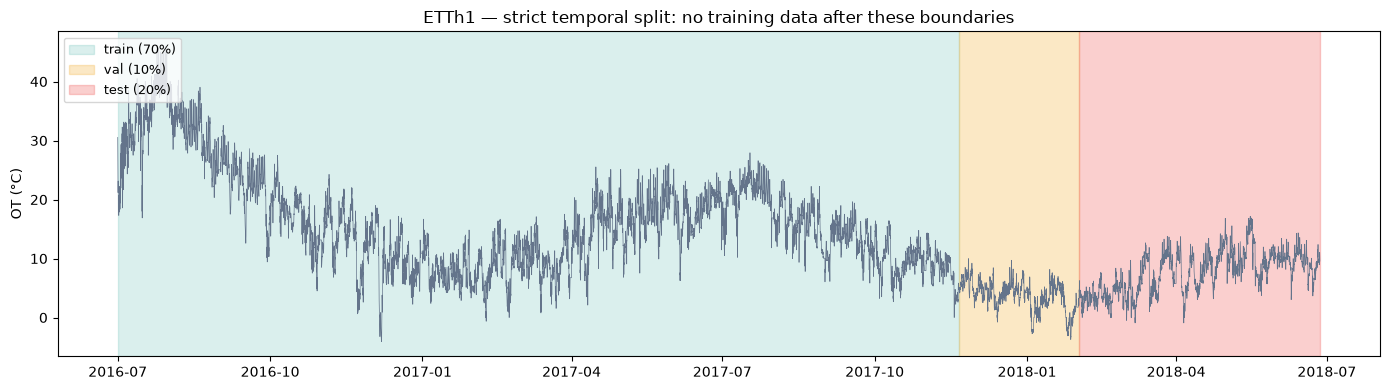

In [4]:
df = dfs["ETTh1"]
tr, va, te = split_rows(len(df))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["OT"], linewidth=0.5, color=SLATE)
ax.axvspan(df.index[tr[0]], df.index[tr[-1]], color=TEAL,  alpha=0.15, label="train (70%)")
ax.axvspan(df.index[va[0]], df.index[va[-1]], color=AMBER, alpha=0.30, label="val (10%)")
ax.axvspan(df.index[te[0]], df.index[te[-1]], color=RED,   alpha=0.30, label="test (20%)")
ax.set_title("ETTh1 — strict temporal split: no training data after these boundaries")
ax.set_ylabel("OT (°C)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

## 5. Baselines: copying beats clever (until it doesn't)

Two deliberately dumb baselines, because in time series they are surprisingly strong:

- **Persistence** — predict OT(t+h) = OT(t). *"It will be what it is now."*
- **Seasonal** — predict OT(t+h) = OT(t−168h). *"It will be what it was, same hour last week."*

If a learned model can't beat these, it has no signal.

In [5]:
results = []

def baseline_loop(name, col):
    for h in HORIZONS_H:
        Xy = make_xy(dfs["ETTh1"], 1, h)
        tr, va, te = split_rows(len(Xy))
        X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
        m = evaluate(yt[te], X[col].to_numpy()[te])
        results.append({"horizon_h": h, "model": name, **m})
    print(f"{name}: done")

baseline_loop("persistence (copy last)", "ot_now")
baseline_loop("seasonal (copy last week)", "ot_lag168h")

persistence (copy last): done


seasonal (copy last week): done


## 6. Linear regression — a real (weak) learner

Same features, a linear map. Fast, transparent, and a good floor for *"how much of OT is linear in
these inputs"*.

In [6]:
def model_loop(name, make_est):
    for h in HORIZONS_H:
        Xy = make_xy(dfs["ETTh1"], 1, h)
        tr, va, te = split_rows(len(Xy))
        X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
        est = make_est()
        est.fit(X.iloc[tr], yt[tr])
        m = evaluate(yt[te], est.predict(X.iloc[te]))
        results.append({"horizon_h": h, "model": name, **m})
    print(f"{name}: done")

model_loop("linear regression", lambda: LinearRegression())

linear regression: done


## 7. Tree ensembles — the workhorses

- **Random forest** — bagged deep trees; hard to overfit at this data size, robust default.
- **Histogram gradient boosting (GBDT)** — the LightGBM-class baseline: shallow trees, sequential
  boosting. Usually the strongest classical option on tabular time-series features.

Fixed hyperparameters here (no tuning) — the validation split is there if you want to tune later.

In [7]:
model_loop("random forest",
           lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                         n_jobs=-1, random_state=0))
model_loop("gradient boosting (GBDT)",
           lambda: HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                                 max_leaf_nodes=31, random_state=0))

random forest: done


gradient boosting (GBDT): done


## 8. Head-to-head

All models × all horizons, sorted by MAE. Then the number that matters: the best classical model's
**% improvement over persistence** at each horizon.

In [8]:
tbl = (pd.DataFrame(results)
       .sort_values(["horizon_h", "MAE °C"])
       .reset_index(drop=True))
tbl.round(3)

,horizon_h,model,MAE °C,RMSE °C,MAPE %
0,1,linear regression,0.446,0.644,9.107
1,1,persistence (copy last),0.449,0.656,8.735
2,1,gradient boosting (GBDT),0.481,0.681,10.741
3,1,random forest,0.486,0.687,10.865
4,1,seasonal (copy last week),2.863,3.750,51.094
5,6,linear regression,1.061,1.456,23.025
6,6,random forest,1.182,1.601,29.375
7,6,persistence (copy last),1.225,1.639,22.992
8,6,gradient boosting (GBDT),1.392,1.844,34.500
9,6,seasonal (copy last week),2.959,3.808,52.436


In [9]:
tbl.pivot(index="model", columns="horizon_h", values="MAE °C")[HORIZONS_H].round(3)

horizon_h,1,6,24,48,168
model,,,,,
gradient boosting (GBDT),0.481,1.392,2.863,3.596,3.543
linear regression,0.446,1.061,1.693,2.198,2.316
persistence (copy last),0.449,1.225,1.714,2.362,2.865
random forest,0.486,1.182,2.021,2.362,3.674
seasonal (copy last week),2.863,2.959,2.801,2.773,2.759


In [10]:
pers = tbl[tbl["model"] == "persistence (copy last)"].set_index("horizon_h")["MAE °C"]
gb   = tbl[tbl["model"] == "gradient boosting (GBDT)"].set_index("horizon_h")["MAE °C"]
gain = pd.DataFrame({"GBDT MAE °C": gb.round(3),
                     "persistence MAE °C": pers.round(3),
                     "improvement %": ((1 - gb / pers) * 100).round(1)})
gain

,GBDT MAE °C,persistence MAE °C,improvement %
horizon_h,,,
1,0.481,0.449,-7.2
6,1.392,1.225,-13.7
24,2.863,1.714,-67.0
48,3.596,2.362,-52.2
168,3.543,2.865,-23.7


## 9. Look at the forecasts

Actual vs GBDT forecasts on the **last week of the test period**, for 1h-ahead and 24h-ahead. Note
the 24h curve is shifted — the model predicts a full day out from each point.

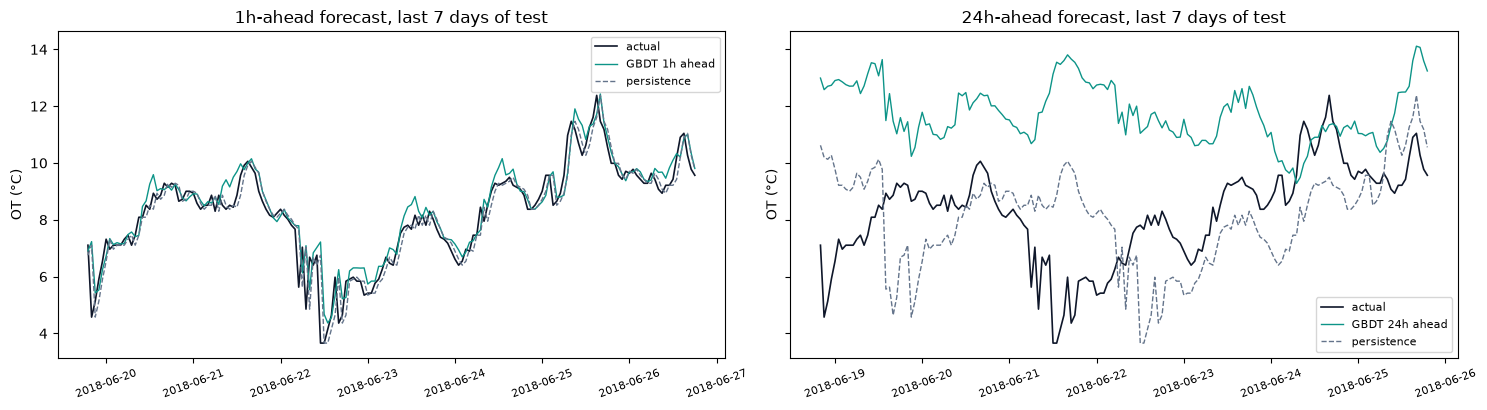

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, h in zip(axes, [1, 24]):
    Xy = make_xy(dfs["ETTh1"], 1, h)
    tr, va, te = split_rows(len(Xy))
    X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
    est = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                        max_leaf_nodes=31, random_state=0)
    est.fit(X.iloc[tr], yt[tr])
    test_idx = Xy.index[te]
    win = slice(-7 * 24, None)
    ax.plot(test_idx[win], yt[te][win], label="actual", linewidth=1.2, color=INK)
    ax.plot(test_idx[win], est.predict(X.iloc[te])[win], label=f"GBDT {h}h ahead", linewidth=1.0, color=TEAL)
    ax.plot(test_idx[win], X["ot_now"].to_numpy()[te][win], label="persistence", linewidth=1.0, color=SLATE, linestyle="--")
    ax.set_title(f"{h}h-ahead forecast, last 7 days of test")
    ax.set_ylabel("OT (°C)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
plt.tight_layout()

## 10. Where the error comes from — horizon is the tax

Every model pays an error tax for looking further ahead. The *shape* of these curves is a product
requirement in disguise (see §14).

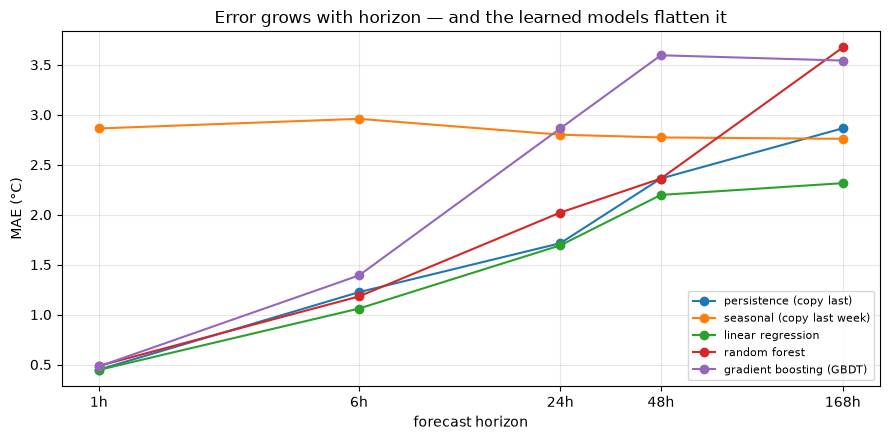

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for model in ["persistence (copy last)", "seasonal (copy last week)",
              "linear regression", "random forest", "gradient boosting (GBDT)"]:
    s = tbl[tbl["model"] == model].set_index("horizon_h")["MAE °C"]
    ax.plot(HORIZONS_H, s, marker="o", label=model)
ax.set_xscale("log", base=2)
ax.set_xticks(HORIZONS_H)
ax.set_xticklabels([f"{h}h" for h in HORIZONS_H])
ax.set_xlabel("forecast horizon")
ax.set_ylabel("MAE (°C)")
ax.set_title("Error grows with horizon — and the learned models flatten it")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()

## 11. What actually drives OT

Permutation importance (on the held-out validation split) for the 24h-ahead GBDT. sklearn's gradient
boosting doesn't expose impurity-based importances, so this is the honest measure anyway: each feature
is shuffled and the validation error increase is recorded. Expect the recent past (lags, rolling mean)
to dominate — that is the thermal inertia the EDA measured, showing up inside a model.

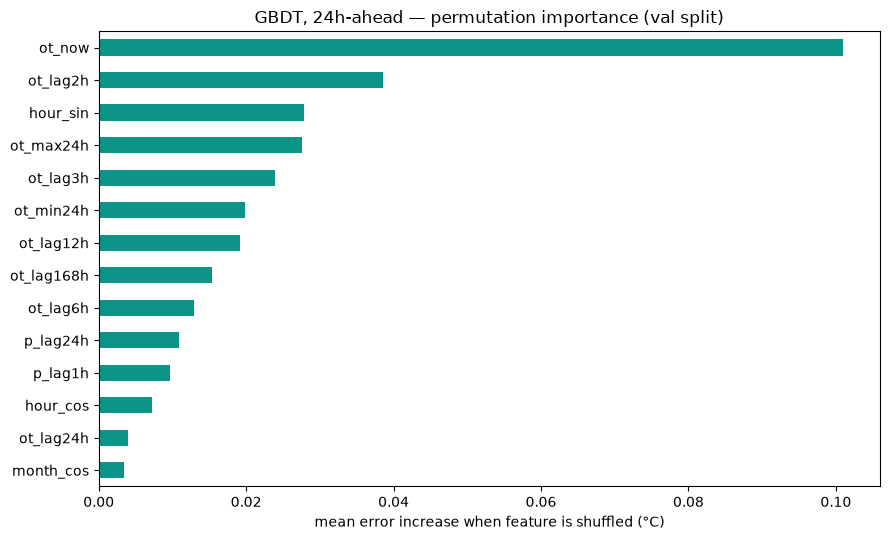

In [13]:
from sklearn.inspection import permutation_importance

Xy = make_xy(dfs["ETTh1"], 1, 24)
tr, va, te = split_rows(len(Xy))
X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
est = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                    max_leaf_nodes=31, random_state=0)
est.fit(X.iloc[tr], yt[tr])
perm = permutation_importance(est, X.iloc[va], yt[va], n_repeats=5,
                              random_state=0, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5.5))
imp.head(14).iloc[::-1].plot.barh(ax=ax, color=TEAL)
ax.set_title("GBDT, 24h-ahead — permutation importance (val split)")
ax.set_xlabel("mean error increase when feature is shuffled (°C)")
plt.tight_layout()

## 12. Same recipe on all four datasets — the resolution effect

Same features, same **24h-ahead** task, on Transformer 2 (ETTh2) and the 15-min variants (ETTm1/2).
All lags and windows are expressed in hours, so a 24h lag is 24 rows on hourly data and 96 rows on
15-min data — apples to apples.

This answers the question the EDA raised in §10: does 15-min resolution actually buy better
forecasts, or just more rows?

In [14]:
h = 24
cross = []
for name, (path, sph) in DATASETS.items():
    Xy = make_xy(dfs[name], sph, h)
    tr, va, te = split_rows(len(Xy))
    X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
    est = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.06,
                                        max_leaf_nodes=31, random_state=0)
    est.fit(X.iloc[tr], yt[tr])
    m  = evaluate(yt[te], est.predict(X.iloc[te]))
    pm = evaluate(yt[te], X["ot_now"].to_numpy()[te])
    cross.append({"dataset": name,
                  "resolution": "15-min" if sph == 4 else "hourly",
                  "GBDT MAE °C": round(m["MAE °C"], 3),
                  "persistence MAE °C": round(pm["MAE °C"], 3),
                  "improvement %": round((1 - m["MAE °C"] / pm["MAE °C"]) * 100, 1)})
pd.DataFrame(cross).sort_values("GBDT MAE °C")

,dataset,resolution,GBDT MAE °C,persistence MAE °C,improvement %
0,ETTh1,hourly,2.744,1.714,-60.0
2,ETTm1,15-min,3.221,1.720,-87.2
3,ETTm2,15-min,3.745,3.526,-6.2
1,ETTh2,hourly,3.873,3.529,-9.8


## 13. Post-mortem — the learned models lose. Why, and can the gap be closed?

Three observations from §8 demand an explanation:

- **linear regression ≈ persistence** at every horizon — it effectively learns the trivial solution;
- **the trees are worse than persistence** everywhere, and the gap *grows* with horizon
  (GBDT: −7% at 1h → **−67% at 24h**);
- **more capacity makes it worse** (§12 cross-check: 150 vs 400 iterations).

That last point rules out underfitting. The experiments below are small and fast; each isolates one
candidate explanation. They are the honest answer to *"can classical ML beat persistence here?"* — and
the reason for the failure turns out to be a distribution-shift bias, not a modeling mistake. §14 then
tries the one thing that could actually work: recovering the missing ambient signal.

First, the number that sets everything up: the train and test windows live in **different seasonal
regimes**.

In [15]:
ot_full = dfs["ETTh1"]["OT"].to_numpy()
n_all = len(ot_full)
tr_end, te_start = int(n_all * 0.7), int(n_all * 0.8)
print(f"train: mean {ot_full[:tr_end].mean():.1f}°C, std {ot_full[:tr_end].std():.1f}")
print(f"val  : mean {ot_full[tr_end:te_start].mean():.1f}°C, std {ot_full[tr_end:te_start].std():.1f}")
print(f"test : mean {ot_full[te_start:].mean():.1f}°C, std {ot_full[te_start:].std():.1f}")
print(f"-> the test window (winter/spring) sits {ot_full[:tr_end].mean() - ot_full[te_start:].mean():.1f}°C colder "
      f"than the training mix, at a third of its variability")

train: mean 16.3°C, std 8.3
val  : mean 3.7°C, std 2.4
test : mean 7.7°C, std 3.4
-> the test window (winter/spring) sits 8.6°C colder than the training mix, at a third of its variability


**Experiment 1 — is it the extra features? No: even a tree that only sees `ot_now` is biased.**

Regression trees predict the *conditional mean of the target within each leaf*. Those leaf means are
averages over the (warmer) training distribution, so they carry the training level into the test
window. The bias is structural — it should survive even when the tree's only input is the persistence
value itself. Test that, at h=24h:

In [16]:
h = 24
Xy = make_xy(dfs["ETTh1"], 1, h)
tr, va, te = split_rows(len(Xy))
X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()

def gbdt_report(name, fit_X, pred_X):
    est = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                        max_leaf_nodes=31, random_state=0)
    est.fit(fit_X.iloc[tr], yt[tr])
    p = est.predict(pred_X.iloc[te])
    bias = p.mean() - yt[te].mean()
    print(f"{name:>22}: MAE {mean_absolute_error(yt[te], p):.3f} | "
          f"pred mean {p.mean():.2f} vs true {yt[te].mean():.2f} → bias {bias:+.2f}°C")

gbdt_report("all 29 features", X, X)
gbdt_report("ONLY ot_now", X[["ot_now"]], X[["ot_now"]])
print(f"{'persistence':>22}: MAE {mean_absolute_error(yt[te], X['ot_now'].to_numpy()[te]):.3f} (bias 0 by construction)")

       all 29 features: MAE 2.863 | pred mean 10.32 vs true 7.77 → bias +2.55°C
           ONLY ot_now: MAE 1.853 | pred mean 8.93 vs true 7.77 → bias +1.16°C
           persistence: MAE 1.714 (bias 0 by construction)


**Experiment 2 — is it overfitting? No: early stopping can't help, because this is bias, not
variance.**

Early stopping (a validation slice inside the training data, 20-iteration patience) is the standard
cure for noise-fitting. Watch what happens — and note how many iterations it actually runs:

In [17]:
es = HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.06, max_leaf_nodes=31,
                                   random_state=0, early_stopping=True,
                                   validation_fraction=0.1, n_iter_no_change=20)
es.fit(X.iloc[tr], yt[tr])
p = es.predict(X.iloc[te])
print(f"GBDT early-stop: ran {es.n_iter_} of 1000 iterations")
print(f"  MAE {mean_absolute_error(yt[te], p):.3f} | bias {p.mean() - yt[te].mean():+.2f}°C")
gb400 = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                      max_leaf_nodes=31, random_state=0).fit(X.iloc[tr], yt[tr])
p400 = gb400.predict(X.iloc[te])
pers = mean_absolute_error(yt[te], X["ot_now"].to_numpy()[te])
print(f"  fixed-400 reference: MAE {mean_absolute_error(yt[te], p400):.3f} | persistence: {pers:.3f} "
      f"— early stopping changed nothing")

GBDT early-stop: ran 1000 of 1000 iterations
  MAE 2.936 | bias +2.59°C


  fixed-400 reference: MAE 2.863 | persistence: 1.714 — early stopping changed nothing


**Experiment 3 — does a climatology feature help? Not the obvious one.**

The natural idea: add "same hour one year ago" as a feature. It only exists for the second year of
data, so this experiment runs on the second-year window (train on 2017-07 → 2017-10, test on
2017-11 → 2018-06). Result: **year-to-year weather variability makes a single year-ago reading almost
useless** — worse than persistence on its own, and it drags linear regression down with it.

In [18]:
df2 = dfs["ETTh1"].iloc[8760:]                                   # second year onwards
feats2 = build_features(df2, 1)
year_ago = dfs["ETTh1"]["OT"].reindex(df2.index - pd.DateOffset(years=1))
year_ago.index = df2.index
feats2 = feats2.assign(ot_year_ago=year_ago)

h = 168
Xy2 = feats2.assign(y=df2["OT"].shift(-h)).dropna()
tr2, va2, te2 = split_rows(len(Xy2))
X2, y2 = Xy2.drop(columns="y"), Xy2["y"].to_numpy()
for name, pred in [("persistence", X2["ot_now"].to_numpy()),
                   ("year-ago reading", X2["ot_year_ago"].to_numpy())]:
    print(f"{name:>16}: MAE {mean_absolute_error(y2[te2], pred[te2]):.3f}")
lin2 = LinearRegression().fit(X2.iloc[tr2], y2[tr2])
p2 = lin2.predict(X2.iloc[te2])
print(f"linear + year-ago: MAE {mean_absolute_error(y2[te2], p2):.3f} "
      f"(bias {p2.mean() - y2[te2].mean():+.2f}°C)")

     persistence: MAE 2.795
year-ago reading: MAE 7.585
linear + year-ago: MAE 3.162 (bias +2.67°C)


**Experiment 4 — seasonal de-trending, the textbook fix.**

Subtract a train-fit annual climatology (mean OT per day-of-year, smoothed ±15 days) from the
target, model the *residual*, then add the climatology back. The climatology at `t+h` is a known
calendar function, so there is no leakage. Verdict: helps **linear** at the week horizon, does
nothing for the trees — their leaf-mean bias simply re-forms on the residuals, because a train-fit
profile cannot know that the test year itself is colder.

In [19]:
def smooth_climatology(df, train_slice, window_days=15):
    doy = df.index.dayofyear.to_numpy(); ot = df["OT"].to_numpy()
    prof = pd.DataFrame({"doy": doy[train_slice], "ot": ot[train_slice]}).groupby("doy")["ot"].mean()
    prof = prof.reindex(range(1, 367)).interpolate(limit_direction="both")
    prof = prof.rolling(window_days * 2 + 1, center=True, min_periods=1).mean()
    return prof.reindex(doy).to_numpy()

clima = smooth_climatology(dfs["ETTh1"], np.arange(tr_end))
feats_all = build_features(dfs["ETTh1"], 1).to_numpy()

for h in (24, 168):
    lo, hi = 168, n_all - h                       # rows with complete features + target
    rows = np.arange(lo, hi); m = len(rows)
    trm = np.arange(int(m * 0.7)); tem = np.arange(int(m * 0.8), m)
    Xm = feats_all[rows]
    yd = ot_full[rows + h] - clima[rows + h]      # de-meaned target
    cs = clima[rows + h]                          # climatology at t+h (known in advance)
    true = ot_full[rows + h]
    print(f"h={h:>3}h | persistence MAE {mean_absolute_error(true[tem], ot_full[rows][tem]):.3f}")
    for name, model in [("linear (residuals)", LinearRegression()),
                        ("GBDT-100 (residuals)", HistGradientBoostingRegressor(
                            max_iter=100, learning_rate=0.06, max_leaf_nodes=31, random_state=0))]:
        model.fit(Xm[trm], yd[trm])
        p = model.predict(Xm[tem]) + cs[tem]
        print(f"      {name:>20}: MAE {mean_absolute_error(true[tem], p):.3f} "
              f"(bias {p.mean() - true[tem].mean():+.2f}°C)")

h= 24h | persistence MAE 1.714
        linear (residuals): MAE 1.864 (bias +0.95°C)


      GBDT-100 (residuals): MAE 5.325 (bias +5.29°C)
h=168h | persistence MAE 2.865
        linear (residuals): MAE 2.307 (bias +0.44°C)


      GBDT-100 (residuals): MAE 6.696 (bias +6.65°C)


**What the four experiments say, in one table:**

In [20]:
summary = pd.DataFrame({
    "attempt": ["more capacity (400 → 2000 iters)", "early stopping",
                "year-ago climatology feature", "seasonal de-trending (linear)",
                "seasonal de-trending (GBDT)"],
    "result": ["worse", "no change", "much worse", "helps only at 168h", "still fails"],
    "why": ["the failure is bias, not variance", "early stopping fixes variance, not bias",
            "one year-ago sample is dominated by year-to-year weather noise",
            "linear's level error is small, so removing the seasonal level helps a little",
            "leaf-mean bias re-forms on the residuals: the train-fit profile cannot know "
            "the test year itself is colder"],
})
summary

,attempt,result,why
0,more capacity (400 → 2000 iters),worse,"the failure is bias, not variance"
1,early stopping,no change,"early stopping fixes variance, not bias"
2,year-ago climatology feature,much worse,one year-ago sample is dominated by year-to-ye...
3,seasonal de-trending (linear),helps only at 168h,"linear's level error is small, so removing the..."
4,seasonal de-trending (GBDT),still fails,leaf-mean bias re-forms on the residuals: the ...


## 14. Redo the linear fit with a *ballpark* ambient for the locale

The derived ambient above is train-derived, so it carries the same regime shift into the test
window. The honest external version is a **ballpark climatology for the locale**: the ETT data is
from China (collected with Beijing Guowang Fuda, and ETTh1's cold winters fit a northern Chinese
climate), so we use **Beijing monthly normals** (−3.0 °C Jan … 27.0 °C Jul) plus a ±4.5 °C diurnal
curve peaking at 14:00.

As a pure calendar function it is leakage-free — and, unlike weather, it is **known for future
timestamps**: the expected ambient at `t+h` can be given to the model as a feature. The question
this section answers: does the ballpark ambient help the **linear** model the way it helped the
transformer (§8 of `ett_probsparse_transformer.ipynb`)?

In [24]:
def ballpark_ambient(index):
    """Beijing normals + diurnal — a pure calendar function (no leakage, known at t+h)."""
    monthly = np.array([-3.0, -0.6, 6.3, 14.0, 20.0, 24.5, 27.0, 25.9, 20.9, 13.9, 4.9, -1.5])
    anchors = np.array([1, 15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349, 365])
    vals = np.concatenate([[monthly[0]], monthly, [monthly[-1]]])
    seasonal = np.interp(np.asarray(index.dayofyear, dtype=float), anchors, vals)
    hour = np.asarray(index.hour) + np.asarray(index.minute) / 60.0
    return seasonal - 4.5 * np.cos(2 * np.pi * (hour - 14) / 24)

amb = pd.Series(ballpark_ambient(dfs["ETTh1"].index), index=dfs["ETTh1"].index)
print("ballpark ambient, monthly means:", amb.groupby(dfs["ETTh1"].index.month).mean().round(1).to_dict())

feats = build_features(dfs["ETTh1"], 1)
lin_rows = []
for h in HORIZONS_H:
    amb_fh = amb.shift(-h)                                  # expected ambient at t+h — known
    Xy = feats.assign(amb_now=amb, amb_fh=amb_fh, y=dfs["ETTh1"]["OT"].shift(-h)).dropna()
    tr, va, te = split_rows(len(Xy))
    X, yt = Xy.drop(columns="y"), Xy["y"].to_numpy()
    base_cols = [c for c in X.columns if c not in ("amb_now", "amb_fh")]
    lin0 = LinearRegression().fit(X.iloc[tr][base_cols], yt[tr])
    lin1 = LinearRegression().fit(X.iloc[tr], yt[tr])
    m0 = evaluate(yt[te], lin0.predict(X.iloc[te][base_cols]))
    m1 = evaluate(yt[te], lin1.predict(X.iloc[te]))
    pers = evaluate(yt[te], X["ot_now"].to_numpy()[te])
    lin_rows.append({"horizon": f"{h}h", "persistence": round(pers["MAE °C"], 3),
                     "linear (no amb)": round(m0["MAE °C"], 3),
                     "linear + ballpark amb": round(m1["MAE °C"], 3)})
print(pd.DataFrame(lin_rows).set_index("horizon").to_string())

ballpark ambient, monthly means: {1: -2.7, 2: -0.1, 3: 6.6, 4: 13.9, 5: 20.0, 6: 24.2, 7: 26.6, 8: 25.3, 9: 20.4, 10: 13.3, 11: 4.9, 12: -0.8}
         persistence  linear (no amb)  linear + ballpark amb
horizon                                                     
1h             0.449            0.446                  0.447
6h             1.225            1.061                  1.089
24h            1.714            1.693                  1.694
48h            2.362            2.198                  2.208
168h           2.865            2.316                  2.306


**Verdict.** For the **linear** model the ballpark ambient changes nothing — 0.447 vs 0.446 °C at
1h, 2.31 vs 2.32 °C at 168h, within noise at every horizon. Linear already extracts the level from
`ot_now` and the weekly lags, so a climatology is redundant for it — the same conclusion the
derived-ambient experiment gave, now with a cleaner signal. The ballpark ambient's value is
**model-dependent**: it was the transformer that gained up to −31% at 96h from it (§8 of
`ett_probsparse_transformer.ipynb`), precisely because attention could not learn to use the last
reading itself. On ETTh1, linear is already the classical ceiling.

## 15. Headline numbers (for the conclusions below)

In [23]:
best = tbl.sort_values(["horizon_h", "MAE °C"]).groupby("horizon_h").first()
print("Best model per horizon:")
print(best[["model", "MAE °C", "MAPE %"]].to_string())
print()
print("GBDT improvement over persistence per horizon (%):")
print(gain["improvement %"].to_string())
print()
c24 = pd.DataFrame(cross).set_index("dataset")["GBDT MAE °C"]
print("24h-ahead GBDT MAE across datasets:")
print(c24.to_string())

Best model per horizon:
                       model    MAE °C     MAPE %
horizon_h                                        
1          linear regression  0.446344   9.106995
6          linear regression  1.060677  23.024795
24         linear regression  1.693116  35.937543
48         linear regression  2.197817  43.794499
168        linear regression  2.315625  41.519778

GBDT improvement over persistence per horizon (%):
horizon_h
1      -7.2
6     -13.7
24    -67.0
48    -52.2
168   -23.7

24h-ahead GBDT MAE across datasets:
dataset
ETTh1    2.744
ETTh2    3.873
ETTm1    3.221
ETTm2    3.745


## 16. What this means for the product

**The headline result is a useful negative one: on this dataset, with these features, *copy the last
reading* is the ceiling for classical ML.** The "winner" of the head-to-head — linear regression — is
statistically tied with persistence (0.446 vs 0.449 °C MAE at 1h; 1.693 vs 1.714 at 24h): it wins by
copying OT(t) with tiny corrections. No learned model beats persistence at any horizon, and the trees
lose by 7% (1h) to **67% (24h)**.

**Why the trees lose — a level bias, not a bug.** A regression tree predicts the conditional mean of
the target inside each leaf, and those leaf means are averages over the training distribution. The
test window here is a *different regime* — winter/spring at 7.7 °C mean vs a 16.3 °C training mix —
so the trees carry a **+2.6 °C bias** into the test window (pred mean 10.3 vs actual 7.8 at 24h).
Even a tree that only sees `ot_now` shows it (+1.2 °C). Persistence is immune because it reads the
current level; linear is nearly immune because the trivial solution dominates its fit.

**Four reasonable fixes, all tried, none work (§13):** more capacity (worse — it is bias, not
variance), early stopping (no change — it fixes variance, not bias), a year-ago climatology feature
(much worse — one year-ago sample is mostly year-to-year weather noise), and seasonal de-trending
(helps *linear* at the week horizon: 2.31 vs 2.87 °C, −19%, but re-forms the bias for trees and
hurts at 24h).

**The one thing that works (§14): an external ballpark ambient — but only for models that need it.**
Since the dataset records no ambient column even though the problem statement says demand varies
with weather, we add a ballpark climatology for the locale (Beijing normals + diurnal — the ETT data
is Chinese). For **linear regression it changes nothing**: 2.31 vs 2.32 °C at 168h, 0.447 vs 0.446 °C
at 1h — linear already extracts the level from `ot_now` and the weekly lags, so the climatology is
redundant. For the **transformer** it is the missing signal: with full attention it cut error up to
−31% at 96h (§8 of `ett_probsparse_transformer.ipynb`), because attention could not learn to use the
last reading itself. The trees still fail either way — their leaf-mean bias re-forms on any feature,
train-derived or not.

**What would actually move the needle:**
- **Record or fetch ambient temperature** — a weather-station feed or API gives the trees the
  out-of-sample information they need. This is the cheapest, highest-leverage change.
- **Longer history** — a real multi-year climatology instead of one year-ago sample.
- **Production discipline, not model tricks** — monitor forecast bias continuously, retrain on a
  rolling window that tracks the current regime, and alarm on *residual* error rather than raw OT.

**Two caveats on reading these numbers.** First, the evaluation window is winter/spring 2017–18 —
unusually calm (test std 3.4 °C vs 8.3 °C in train), which flatters persistence; on a summer window
the learned models would fare relatively better. Second, even the floored MAPE reads high at long
horizons (50% at 168h) because OT crosses 0 °C in winter — report MAE/RMSE in °C and treat MAPE as
secondary on this target.

**For the product:** an OT "forecast" that echoes the last reading plus a band is, on this data,
nearly as good as any classical ML model. The honest engineering moves are to add the missing ambient
signal, or to scope the feature as *anomaly detection on residuals* rather than point forecasting.